Let's test the idea that the *area* under the curves is responsible for the total variance of these operators (whatever that means!)

Something that I do think is true is that we can treat the structure factor as a response function to momentum excitations.

In [1]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22441/3373328149.py:14: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22441/3373328149.py:15: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22441/3373328149.py:15: RuntimeWarning: invalid value encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")


Text(0.5, 0, 'r')

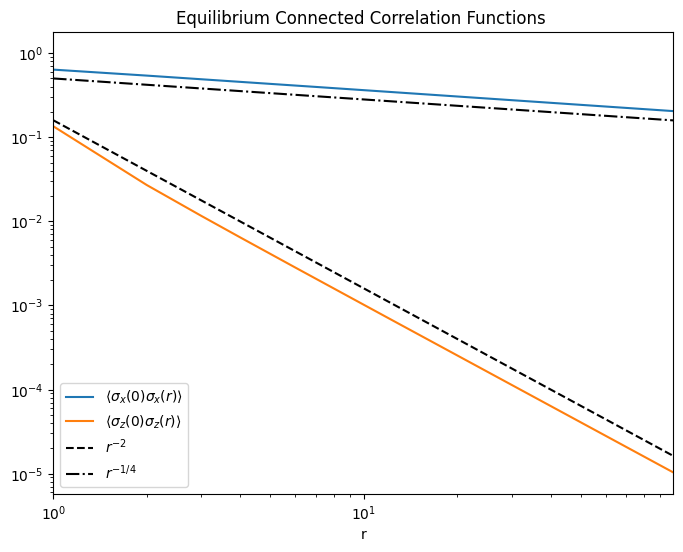

In [43]:
r = np.arange(-100,100)

xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"

C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])


plt.figure(figsize=(8,6))

plot(r,C_xx,label= xx_lab)
plot(r,C_zz,label= zz_lab)
plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
legend()
xlim(1,max(r))
loglog()
title("Equilibrium Connected Correlation Functions ")
xlabel("r")

XX= 1.281564748878177
ZZ= 6.366356882562533e-05


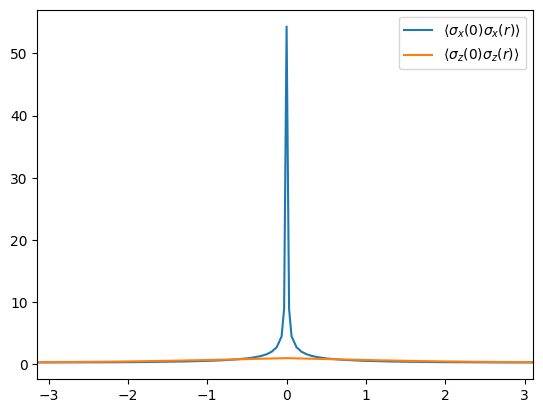

In [40]:
def K(r):
    return fftshift(fftfreq(len(r),1))*2*pi

def FT(x):
    return fftshift(fft(x))


k = K(r)
F_xx = FT(C_xx)
F_zz = FT(C_zz)

plot(k,abs(F_xx),label = xx_lab)
plot(k,abs(F_zz),label=  zz_lab)
xlim(min(k),max(k))
legend()


dk = k[1]-k[0]
print(f"XX= {np.real(sum(F_xx)*dk)}")
print(f"ZZ= {np.real(sum(F_zz)*dk)}")


So the idea here is that $S_{zz}(k)$ is very weak and this operator doesnt fluctuate or something. Or maybe that it's not so responsive to quenches.



# Let's Quench

In [105]:
taus = np.logspace(-1,2.5,30)

import kibble_zurek as kibble_x
import time_evolved_z_correlators as kibble_z

In [148]:
L = 500
states = [kibble_x.state(L,tau,0) for tau in taus]

rho = array([sigma_x([0,1])- kibble_x.sigma_general([0,1],s) for s in states])

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


In [107]:
r = np.arange(-100,100)
quenched_xx = [array([kibble_x.sigma_general([0,ri],s) for ri in tqdm(r)]) for s in states]


  0%|          | 0/200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 200/200 [00:06<00:00, 29.79it/s] 


In [108]:
quenched_zz = [array([kibble_z.sigma_general([0,ri],s)-kibble_z.sigma_general([0],s)**2 for ri in tqdm(r)]) for s in states]

  0%|          | 0/200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
100%|██████████| 200/200 [00:00<00:00, 8766.62it/s]


100%|██████████| 200/200 [00:00<00:00, 13941.05it/s]


ValueError: x and y must have same first dimension, but have shapes (400,) and (200,)

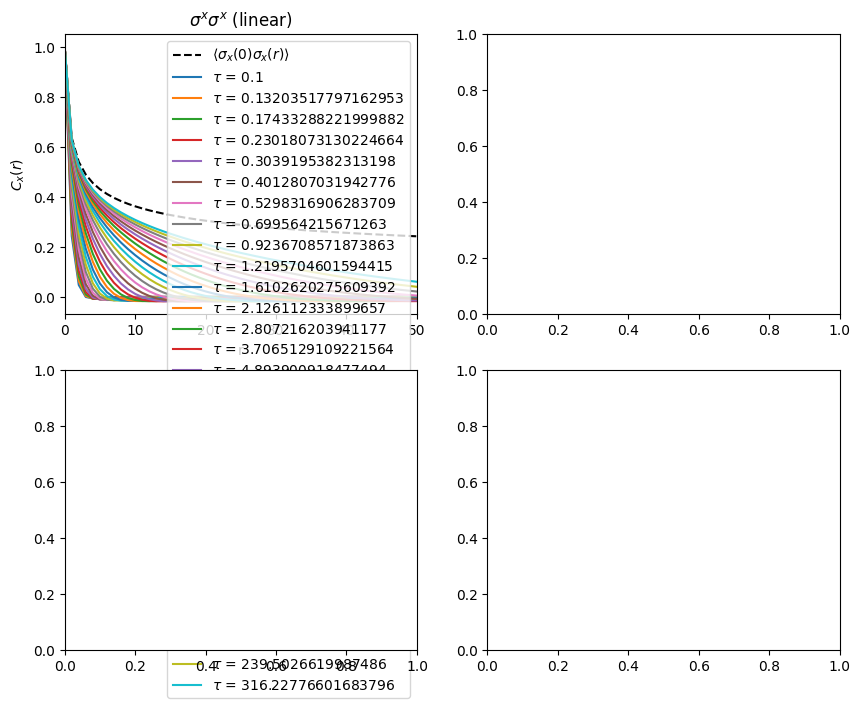

In [109]:
ri = np.arange(-200, 200)
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# --- linear scale σ^xσ^
# 
# x ---
axs[0, 0].plot(r, C_xx, "--k", label=xx_lab)
for i, tau in enumerate(taus):
    xx = quenched_xx[i]
    axs[0, 0].plot(r, xx, label=rf"$\tau$ = {tau}")
axs[0, 0].set_xlabel("r")
axs[0, 0].set_ylabel(r"$C_x(r)$")
axs[0, 0].set_xlim(0, 50)
axs[0, 0].legend()
axs[0, 0].set_title(r"$\sigma^x\sigma^x$ (linear)")

# --- linear scale σ^zσ^z ---
axs[0, 1].plot(ri, C_zz, "-.k", label=zz_lab)
for i, tau in enumerate(taus):
    zz = quenched_zz[i]
    axs[0, 1].scatter(r, zz, s=5, label=rf"$\tau$ = {tau}")
axs[0, 1].set_xlabel("r")
axs[0, 1].set_ylabel(r"$C_z(r)$")
axs[0, 1].set_xlim(0, 50)
axs[0, 1].legend()
axs[0, 1].set_title(r"$\sigma^z\sigma^z$ (linear)")

# --- log scale σ^xσ^x ---
axs[1, 0].plot(ri, C_xx, "--k", label=xx_lab)
for i, tau in enumerate(taus):
    xx = quenched_xx[i]
    axs[1, 0].plot(r, xx, label=rf"$\tau$ = {tau}")
axs[1, 0].set_xscale("log")
axs[1, 0].set_xlim(1, 100)
axs[1, 0].set_xlabel("r (log scale)")
axs[1, 0].set_ylabel(r"$C_x(r)$")
axs[1, 0].legend()
axs[1, 0].set_title(r"$\sigma^x\sigma^x$ (log)")

# --- log scale σ^zσ^z ---
axs[1, 1].plot(ri, C_zz, "-.k", label=zz_lab)
for i, tau in enumerate(taus):
    zz = quenched_zz[i]
    axs[1, 1].scatter(r, zz, s=5, label=rf"$\tau$ = {tau}")
axs[1, 1].set_xscale("log")
axs[1, 1].set_xlim(1, 100)
axs[1, 1].set_xlabel("r (log scale)")
axs[1, 1].set_ylabel(r"$C_z(r)$")
axs[1, 1].legend()
axs[1, 1].set_title(r"$\sigma^z\sigma^z$ (log)")

plt.tight_layout()
plt.show()


We see quite plainly that the $\sigma_x \sigma_x$ correlation is significantly more impacted by quenches than the short range correlators associated with the z direction.

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22441/3667494672.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


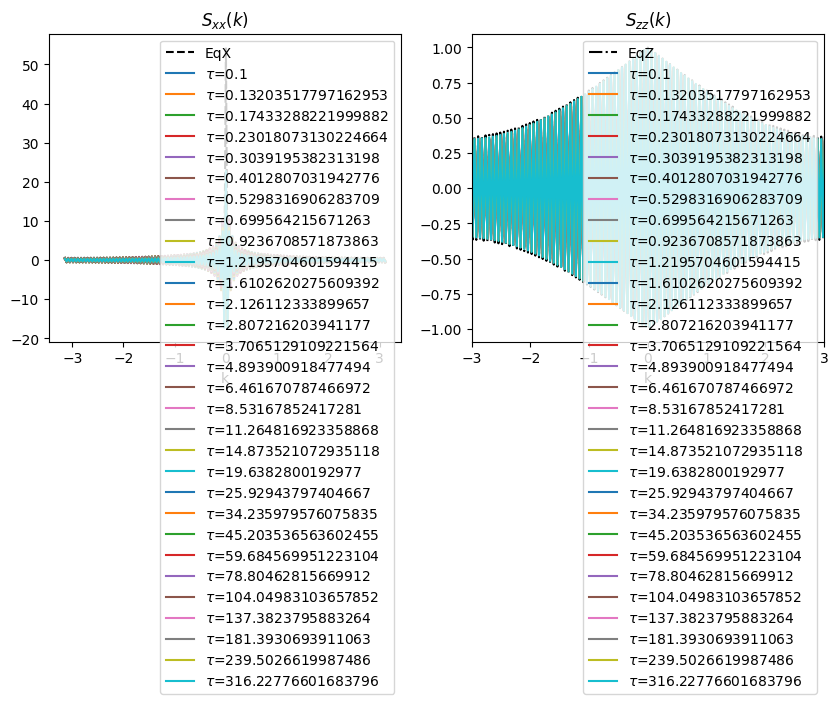

In [110]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
k = K(r)
ki = K(r)
# --- σ^xσ^x structure factor ---
area_x = []
dk = k[1]-k[0]
axs[0].plot(ki, np.real(FT(C_xx)), '--k', label="EqX")
for i, tau in enumerate(taus):
    F_xx = FT(quenched_xx[i])
    area_x.append((sum((F_xx)*dk)))
    axs[0].plot(k, (F_xx), label=rf"$\tau$={tau}")
#axs[0].set_xlim(-1, 1)
#axs[0].set_ylim(0, 0.05)
axs[0].legend()
axs[0].set_title(r"$S_{xx}(k)$")
axs[0].set_xlabel("k")

# --- σ^zσ^z structure factor ---
axs[1].plot(ki, np.real(FT(C_zz)), '-.k', label="EqZ")
area_z = []
for i, tau in enumerate(taus):
    F_zz = FT(quenched_zz[i])
    area_z.append((sum((F_zz))*dk))
    axs[1].plot(k, (F_zz) ,label=rf"$\tau$={tau}")
axs[1].set_xlim(-3, 3)
#axs[1].set_ylim(0, 0.01)

axs[1].legend()
axs[1].set_title(r"$S_{zz}(k)$")
axs[1].set_xlabel("k")

plt.tight_layout()
plt.show()


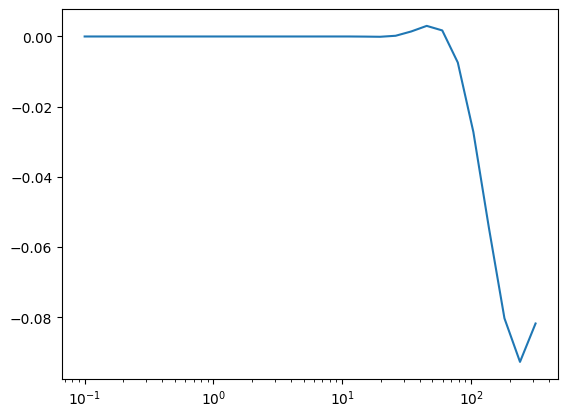

In [111]:
plot(taus,area_x)
xscale("log")

In [79]:
print(np.max(np.abs(C_xx)))
print(np.sum(C_xx))


1.0
54.31648039360935


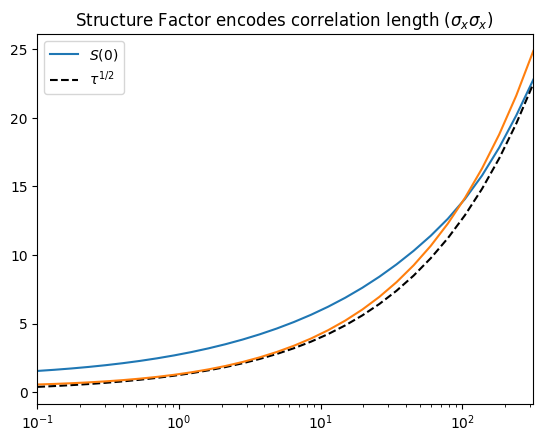

In [152]:
xi =[ ]
for i, tau in enumerate(taus):
    F_xx = FT(quenched_xx[i])
    xi+=[((np.real(F_xx[k==0])))]

plot(taus,xi,label=r"$S(0)$")
plot(taus,taus**(1/2)/taus[0]**(1/2)/2.5,"--k",label=r"$\tau^{1/2}$")
xlim(taus[0],taus[-1])

xi_eq = 1/rho
plot(taus,xi_eq/sqrt(2)/pi)
xscale("log")
title(r"Structure Factor encodes correlation length ($\sigma_x \sigma_x$) ")
legend()


In [87]:
for i, tau in enumerate(taus):
    F_xx = FT(quenched_xx[i])
    print(np.sum(np.real(F_xx))*dk, np.sum(np.abs(F_xx))*dk)


-2.7902947984068896e-16 6.283185307179551
-1.6741768790441338e-16 6.283185307179551
1.7721671076612822e-06 6.283185307179551
-0.023766841078276486 6.283185307179551


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22441/1931432957.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = float(np.dot(xi_eq, xi) / np.dot(xi_eq, xi_eq))


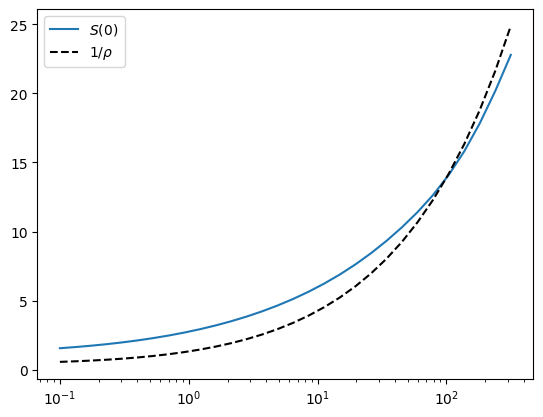

In [171]:
import numpy as np
import matplotlib.pyplot as plt

xi = np.asarray(xi, float)
xi_eq = np.asarray(xi_eq, float)

c = float(np.dot(xi_eq, xi) / np.dot(xi_eq, xi_eq))

plt.plot(taus, xi, label=r'$S(0)$ ')
plt.plot(taus, c * xi_eq, '--k', label=rf'$1/\rho$')
plt.xscale('log')
plt.legend()
plt.show()


In [172]:
r = np.arange(-100,100)
n = 1
PP_1 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

  0%|          | 0/30 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 30/30 [03:18<00:00,  6.62s/it]


In [173]:
r = np.arange(-100,100)
n = 2
PP_2 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

100%|██████████| 30/30 [23:38<00:00, 47.28s/it] 


In [174]:
r = np.arange(-100,100)
n = 3
PP_3 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

  0%|          | 0/30 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 30/30 [1:06:54<00:00, 133.81s/it]


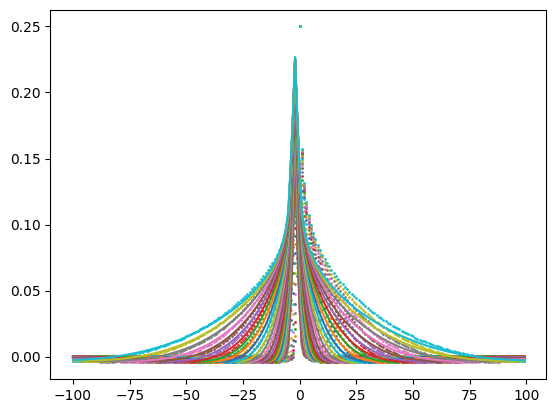

In [192]:
for p in PP_3[0]:
    plot(r,p)
for p in PP_1[0]:
    scatter(r,p,s=1)

In [199]:
FF_PP1= [FT([P]) for P in PP_1[0]]
peaks1 = []
for f in FF_PP1:
    peaks1+=[(f[0][k==0])]
FF_PP2= [FT([P]) for P in PP_2[0]]
peaks2 = []
for f in FF_PP2:
    peaks2+=[(f[0][k==0])]
FF_PP3= [FT([P]) for P in PP_3[0]]
peaks3 = []
for f in FF_PP3:
    peaks3+=[(f[0][k==0])]

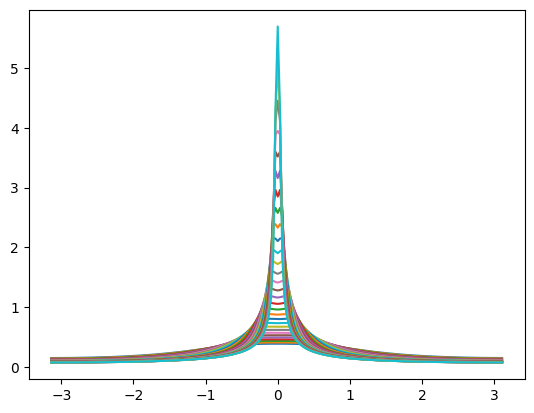

In [200]:
for f in FF_PP1:
    plot(k,abs(f[0]))

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


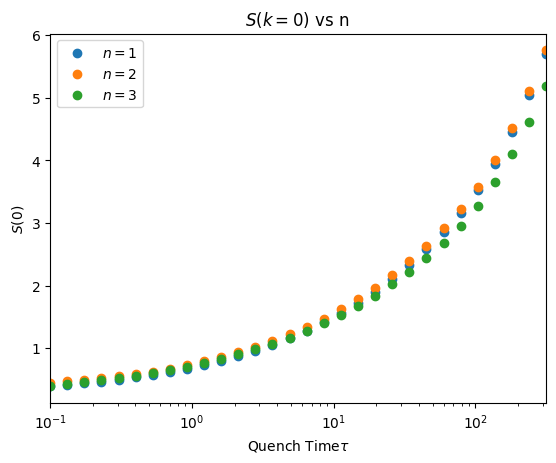

In [217]:
scatter(taus,peaks1,label=r"$n=1$")
scatter(taus,peaks2,label=r"$n=2$")
scatter(taus,peaks3,label=r"$n=3$")

xlabel(r"Quench Time$\tau$")
legend()
ylabel(r"$S(0)$")
xlim(taus[0],taus[-1])
title(r"$S(k=0)$ vs n ")
xscale("log")
#yscale("log")